In [5]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [6]:
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import numpy as np

# 머신러닝/딥러닝 : 데이터의 법칙성을 추출
- 다양한 분야에서 응용 : 글씨인식, 문장분류, 질병진단, ....
※ ML/DL의 종류
- 지도학습(독립=입력변수와 종속=타겟=출력변수가 모두 주어졌을 경우)
    회귀분석(타겟변수가 연속성) vs 분류분석(multi, binary)
- 비지도학습(입력변수만)
    군집화
- 강화학습

※ 지도학습에서의 ML, DL 프로그래밍 방식
1. 데이터 셋 확보(csv, 크롤링을 통한 input=입력변수, target=종속변수)
    원본 데이터 및 시뮬레이션을 통해 데이터 생성
2. 전처리
    스케일 조정
    훈련셋(학습셋), 검증셋, 시험셋(테스트셋) 
    학습 및 평가 가능한 포맷으로 변환(numpy, DataFrame)
3. 모델 구성
    Sequential 객체 생성한 뒤 필요한 층을 add()함수로 추가
4. 모델 학습과정 설정
    compile()함수 이용. 손실함수, optimizer, metrics(평가지표)
5. 모델 학습시키기 (ft. 학습과정 지켜보기)
    fit()함수 이용 - 훈련셋 입력= 독립변수, 훈련셋타겟=종속변수, 학습횟수, 검증셋
6. 모델 평가
    시험셋(테스트셋)을 인자로 넣은 evaluate()함수 이용, 그래프
7. 모델 사용
    perdict() 이용. 입력 데이터는 2차원 [[0]] 데이터
8. 모델 저장
    save()함수 이용해서 저장. 저장된 모델은 load_model()함수를 이용해서 불러올 수 있음



# 1. 데이터 셋 생성
# 2. 데이터 전처리

In [7]:
# 학습데이터 = 훈련데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,4,6,8,10,12,14,16,18]*10)
x_train.shape, y_train.shape
# 검증데이터
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,4,6,8,10,12,14,16,18])
# 테스트셋 = 심험데이터
x_test = np.array([1,2,3,4,5,6,7,8,9])
y_test = np.array([2,4,6,8,10,12,14,16,18])
x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape

((90,), (9,), (9,), (90,), (9,), (9,))

In [8]:
# 인코딩 종류
data = np.array(['a','b','c','d'])
print('원 데이터 :', data)
from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# le.fit(data)

labeled_data = le.fit_transform(data)
print('라벨인코딩된 데이터 :', labeled_data)
one_hot_encoded_data = to_categorical(labeled_data)
print('원핫인코딩된 데이터', one_hot_encoded_data)

원 데이터 : ['a' 'b' 'c' 'd']


NameError: name 'le' is not defined

In [10]:
# 분류분석을 위기 위해, target을 원핫인코딩(라벨링 전환)
data = np.array([1,2,2,4,2])
print(data)
categorical_one_hot = to_categorical(data)
print('to_categorical을 이용한 원핫인코딩:',categorical_one_hot)
import pandas as pd
get_dumies_ont_hot = pd.get_dummies(data)
display('get_dumies를 이용한 원핫인코딩 :', get_dumies_ont_hot)
print(type(categorical_one_hot))
print(type(get_dumies_ont_hot))

[1 2 2 4 2]
to_categorical을 이용한 원핫인코딩: [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]


'get_dumies를 이용한 원핫인코딩 :'

,1,2,4
0,1,0,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,1,0


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


In [11]:
# 분류분석을 위한 ratget 변수 라벨링 전환(=원핫인코딩)
Y_train = to_categorical(y_train, 19)
Y_train[0]
Y_val= to_categorical(y_val)
Y_test = to_categorical(y_test)

In [12]:
print('훈련데이터셋 구조:', x_train.shape, Y_train.shape) # 독립변수 1개, 타겟변수 19
print('검증셋 구조:', x_val.shape, Y_val.shape)
print('테스트셋 구조:', x_test.shape, Y_test.shape)

훈련데이터셋 구조: (90,) (90, 19)
검증셋 구조: (9,) (9, 19)
테스트셋 구조: (9,) (9, 19)


# 3. 모델구성하기

In [13]:
model = Sequential()
model.add(Input(shape=(1,))) # 입력층 
model.add(Dense(units=38, activation='sigmoid')) # units 출력수, 활성화 함수:relu, tanh, sigmoid, elu
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=19, activation='softmax'))
# softmax : 모든 출력 결과의 합이 1. 분류분석 마지막 Layer(출력층) 에서 activation으로 사용
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습과정 설정

In [14]:
model.compile(loss="categorical_crossentropy", # 분류분석에서의 손실함수(원핫인코딩有)
             optimizer='sgd',
             metrics=['accuracy']) # 평가지표 : accuracy


# 5. 모델 학습 시키기

In [15]:
hist = model.fit(x_train, Y_train,
                epochs=300,
                batch_size=10,
                verbose=2, # 학습결과 출력 옵션 0 : 출력없음, 1: 기본값, 2: 에포크별로그 상세출력
                validation_data=(x_val, Y_val)
                )

Epoch 1/300
9/9 - 1s - loss: 2.9945 - accuracy: 0.0000e+00 - val_loss: 2.8399 - val_accuracy: 0.1111 - 563ms/epoch - 63ms/step
Epoch 2/300
9/9 - 0s - loss: 2.7770 - accuracy: 0.1444 - val_loss: 2.6881 - val_accuracy: 0.1111 - 45ms/epoch - 5ms/step
Epoch 3/300
9/9 - 0s - loss: 2.6559 - accuracy: 0.0111 - val_loss: 2.5933 - val_accuracy: 0.1111 - 41ms/epoch - 5ms/step
Epoch 4/300
9/9 - 0s - loss: 2.5772 - accuracy: 0.0778 - val_loss: 2.5303 - val_accuracy: 0.1111 - 41ms/epoch - 5ms/step
Epoch 5/300
9/9 - 0s - loss: 2.5241 - accuracy: 0.0667 - val_loss: 2.4821 - val_accuracy: 0.1111 - 43ms/epoch - 5ms/step
Epoch 6/300
9/9 - 0s - loss: 2.4817 - accuracy: 0.1111 - val_loss: 2.4428 - val_accuracy: 0.1111 - 44ms/epoch - 5ms/step
Epoch 7/300
9/9 - 0s - loss: 2.4399 - accuracy: 0.1111 - val_loss: 2.4092 - val_accuracy: 0.1111 - 46ms/epoch - 5ms/step
Epoch 8/300
9/9 - 0s - loss: 2.4127 - accuracy: 0.0778 - val_loss: 2.3801 - val_accuracy: 0.1111 - 37ms/epoch - 4ms/step
Epoch 9/300
9/9 - 0s - los

Epoch 69/300
9/9 - 0s - loss: 1.6817 - accuracy: 0.3556 - val_loss: 1.6370 - val_accuracy: 0.3333 - 40ms/epoch - 4ms/step
Epoch 70/300
9/9 - 0s - loss: 1.6673 - accuracy: 0.2889 - val_loss: 1.6260 - val_accuracy: 0.3333 - 39ms/epoch - 4ms/step
Epoch 71/300
9/9 - 0s - loss: 1.6484 - accuracy: 0.2889 - val_loss: 1.6162 - val_accuracy: 0.6667 - 41ms/epoch - 5ms/step
Epoch 72/300
9/9 - 0s - loss: 1.6375 - accuracy: 0.4222 - val_loss: 1.6044 - val_accuracy: 0.5556 - 45ms/epoch - 5ms/step
Epoch 73/300
9/9 - 0s - loss: 1.6227 - accuracy: 0.3667 - val_loss: 1.5921 - val_accuracy: 0.4444 - 37ms/epoch - 4ms/step
Epoch 74/300
9/9 - 0s - loss: 1.6070 - accuracy: 0.4111 - val_loss: 1.5802 - val_accuracy: 0.5556 - 41ms/epoch - 5ms/step
Epoch 75/300
9/9 - 0s - loss: 1.5944 - accuracy: 0.4111 - val_loss: 1.5696 - val_accuracy: 0.3333 - 40ms/epoch - 4ms/step
Epoch 76/300
9/9 - 0s - loss: 1.5945 - accuracy: 0.3444 - val_loss: 1.5589 - val_accuracy: 0.4444 - 45ms/epoch - 5ms/step
Epoch 77/300
9/9 - 0s - 

Epoch 136/300
9/9 - 0s - loss: 1.1105 - accuracy: 0.7000 - val_loss: 1.0755 - val_accuracy: 0.7778 - 40ms/epoch - 4ms/step
Epoch 137/300
9/9 - 0s - loss: 1.0927 - accuracy: 0.6889 - val_loss: 1.0710 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 138/300
9/9 - 0s - loss: 1.0921 - accuracy: 0.7889 - val_loss: 1.0653 - val_accuracy: 0.7778 - 41ms/epoch - 5ms/step
Epoch 139/300
9/9 - 0s - loss: 1.0835 - accuracy: 0.7778 - val_loss: 1.0570 - val_accuracy: 0.7778 - 45ms/epoch - 5ms/step
Epoch 140/300
9/9 - 0s - loss: 1.0802 - accuracy: 0.7889 - val_loss: 1.0544 - val_accuracy: 0.7778 - 43ms/epoch - 5ms/step
Epoch 141/300
9/9 - 0s - loss: 1.0723 - accuracy: 0.7556 - val_loss: 1.0459 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 142/300
9/9 - 0s - loss: 1.0703 - accuracy: 0.8444 - val_loss: 1.0405 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 143/300
9/9 - 0s - loss: 1.0645 - accuracy: 0.7444 - val_loss: 1.0375 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 144/300
9/

Epoch 203/300
9/9 - 0s - loss: 0.7857 - accuracy: 0.8333 - val_loss: 0.7588 - val_accuracy: 0.8889 - 39ms/epoch - 4ms/step
Epoch 204/300
9/9 - 0s - loss: 0.7734 - accuracy: 0.9556 - val_loss: 0.7472 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 205/300
9/9 - 0s - loss: 0.7711 - accuracy: 0.8778 - val_loss: 0.7434 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 206/300
9/9 - 0s - loss: 0.7790 - accuracy: 0.8556 - val_loss: 0.7449 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 207/300
9/9 - 0s - loss: 0.7601 - accuracy: 0.8667 - val_loss: 0.7430 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 208/300
9/9 - 0s - loss: 0.7796 - accuracy: 0.8556 - val_loss: 0.7289 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 209/300
9/9 - 0s - loss: 0.7580 - accuracy: 0.9111 - val_loss: 0.7278 - val_accuracy: 1.0000 - 40ms/epoch - 4ms/step
Epoch 210/300
9/9 - 0s - loss: 0.7476 - accuracy: 0.8778 - val_loss: 0.7298 - val_accuracy: 0.7778 - 46ms/epoch - 5ms/step
Epoch 211/300
9/

Epoch 270/300
9/9 - 0s - loss: 0.5466 - accuracy: 0.9778 - val_loss: 0.5310 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 271/300
9/9 - 0s - loss: 0.5587 - accuracy: 0.9444 - val_loss: 0.5256 - val_accuracy: 0.8889 - 49ms/epoch - 5ms/step
Epoch 272/300
9/9 - 0s - loss: 0.5424 - accuracy: 0.9444 - val_loss: 0.5411 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 273/300
9/9 - 0s - loss: 0.5478 - accuracy: 0.9444 - val_loss: 0.5305 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 274/300
9/9 - 0s - loss: 0.5345 - accuracy: 0.9333 - val_loss: 0.5311 - val_accuracy: 1.0000 - 39ms/epoch - 4ms/step
Epoch 275/300
9/9 - 0s - loss: 0.5388 - accuracy: 0.9000 - val_loss: 0.5109 - val_accuracy: 1.0000 - 44ms/epoch - 5ms/step
Epoch 276/300
9/9 - 0s - loss: 0.5578 - accuracy: 0.9444 - val_loss: 0.5222 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 277/300
9/9 - 0s - loss: 0.5404 - accuracy: 0.9667 - val_loss: 0.5037 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 278/300
9/

# 6. 모델 평가하기(모델 학습과정 살펴보고, evalute)

In [17]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

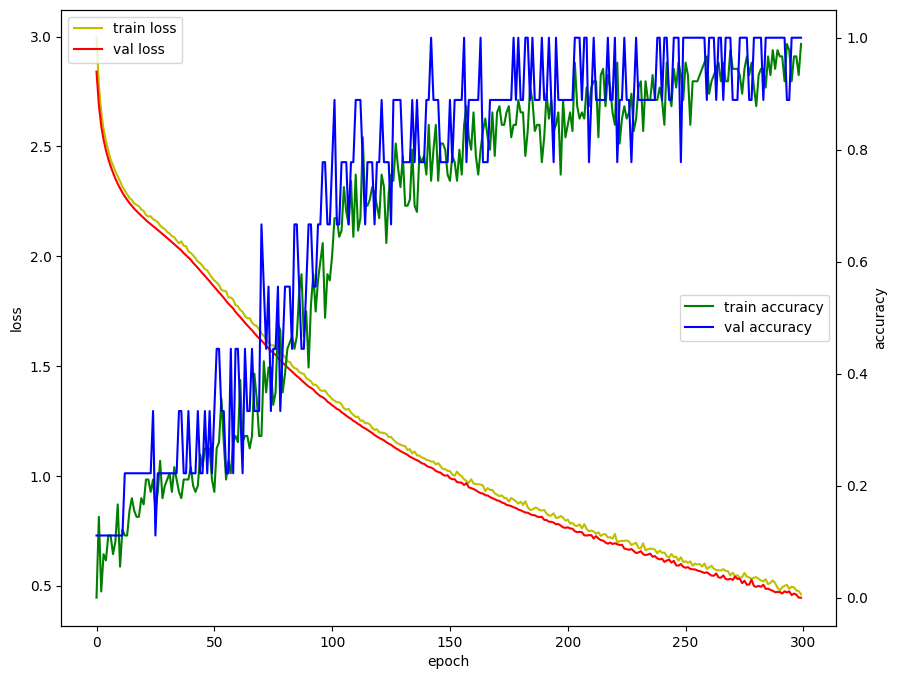

In [25]:
# 모델 학습과정 시각화
import matplotlib.pyplot as plt
fi, loss_ax = plt.subplots(figsize=(10,8))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='upper left')
acc_ax.legend(loc='center right')
plt.show()

In [26]:
# 모델 평가
score = model.evaluate(x_test, Y_test, batch_size=1)

9/9 [==============================] - 0s 2ms/step - loss: 0.4447 - accuracy: 1.0000


In [27]:
score # loss, accuracy

[0.44474369287490845, 1.0]

In [28]:
print('평가된 loss:', score[0])
print('평가된 accuracy:', score[1]*100, '%')

평가된 loss: 0.44474369287490845
평가된 accuracy: 100.0 %


# 7. 모델 사용하기

In [35]:
H = model.predict(np.array([2]))
H

1/1 [==============================] - 0s 37ms/step


array([[8.5496687e-14, 4.4579561e-12, 9.6122332e-02, 4.7699823e-11,
        7.7305180e-01, 1.3442729e-08, 1.3020664e-01, 2.7570444e-11,
        6.1848352e-04, 8.5586699e-15, 7.5931365e-07, 4.2002855e-12,
        1.8005650e-09, 5.4767142e-11, 3.5941488e-15, 2.2100985e-10,
        1.6061378e-18, 6.5415512e-12, 4.6056388e-23]], dtype=float32)

In [33]:
# 분류분석의 예측은  predict()후 argmax()
H = model.predict(np.array([2])).argmax()

1/1 [==============================] - 0s 19ms/step


In [37]:
# 4를 몇 % 확률로 예측했는지
H[0, H.argmax()]*100

77.30517983436584

# 7. 모델 저장하기

In [39]:
# model.save('model/02_deep.h5')
from tensorflow.keras.models import save_model
save_model(model, 'model/02_deep.h5')

# 저장된 모델 사용하기

In [ ]:
from tensorflow.keras.models import load_model
model2 = load_model('model/02_deep.h5')